In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np


In [7]:
#Load Data set
DATASET_PATH =  r"C:\Users\94772\Desktop\Abdullah_project\Tamil_Character_Recognition\dataset_raw"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = val_test_ds.take(int(0.5 * len(val_test_ds)))
test_ds = val_test_ds.skip(int(0.5 * len(val_test_ds)))

NUM_CLASSES = len(train_ds.class_names)
print("Classes =", NUM_CLASSES)


Found 24700 files belonging to 247 classes.
Using 17290 files for training.
Found 24700 files belonging to 247 classes.
Using 7410 files for validation.
Classes = 247


In [21]:
#prefetch
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)


In [22]:
#EfficientNet Transfer Learning
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False   # Freeze feature extractor

inputs = layers.Input(shape=(224,224,3))

x = tf.keras.applications.efficientnet.preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model_3 = models.Model(inputs, outputs)

model_3.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 247)            │       316,407 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,365,978 (16.65 MB)

 Trainable params: 316,407 (1.21 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [23]:
# compile
model_3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
#Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model_3.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


In [24]:
history_3 = model_3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0510 - loss: 5.1253
Epoch 1: val_accuracy improved from -inf to 0.23249, saving model to best_model_3.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 904s 1s/step - accuracy: 0.0511 - loss: 5.1244 - val_accuracy: 0.2325 - val_loss: 3.7817
Epoch 2/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2298 - loss: 3.6581
Epoch 2: val_accuracy improved from 0.23249 to 0.34079, saving model to best_model_3.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 752s 1s/step - accuracy: 0.2298 - loss: 3.6578 - val_accuracy: 0.3408 - val_loss: 3.1180
Epoch 3/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3213 - loss: 3.0763
Epoch 3: val_accuracy improved from 0.34079 to 0.40652, saving model to best_model_3.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 717s 1s/step - accuracy: 0.3213 - loss: 3.0761 - val_accuracy: 0.4065 - val_loss: 2.7467
Epoch 4/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3880 - loss: 2.7161
Epoch 4: val_accuracy improved from 

In [25]:
loss, acc = model_3.evaluate(test_ds)
print("Test Accuracy =", acc)
print("Test Loss =", loss)


116/116 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6469 - loss: 1.3304
Test Accuracy = 0.6438615322113037
Test Loss = 1.363471508026123


## Fine-Tuning

In [26]:
import tensorflow as tf

model_4 = tf.keras.models.load_model("best_model_3.keras")


In [27]:
model_4.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 247)            │       316,407 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,998,794 (19.07 MB)

 Trainable params: 316,407 (1.21 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 632,816 (2.41 MB)

In [28]:
#Unfreeze Top Layers of EfficientNet
base_model = model_4.get_layer("efficientnetb0")
  # EfficientNet block

base_model.trainable = True

# Freeze bottom 70% and train only top 30%
for layer in base_model.layers[:200]:
    layer.trainable = False
#EfficientNetB0 has ~237 layers, adjust if needed

In [29]:
#Recompile With Smaller Learning Rate
model_4.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [30]:
#Callback
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model_4.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


In [31]:
#Train
history_4 = model_4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[checkpoint, early_stop]
)



Epoch 1/40
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2742 - loss: 3.4958
Epoch 1: val_accuracy improved from -inf to 0.47791, saving model to best_model_4.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 1046s 2s/step - accuracy: 0.2742 - loss: 3.4949 - val_accuracy: 0.4779 - val_loss: 2.0204
Epoch 2/40
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4185 - loss: 2.3087
Epoch 2: val_accuracy improved from 0.47791 to 0.56439, saving model to best_model_4.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 863s 2s/step - accuracy: 0.4186 - loss: 2.3084 - val_accuracy: 0.5644 - val_loss: 1.6353
Epoch 3/40
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5062 - loss: 1.8411
Epoch 3: val_accuracy improved from 0.56439 to 0.61045, saving model to best_model_4.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 875s 2s/step - accuracy: 0.5062 - loss: 1.8410 - val_accuracy: 0.6105 - val_loss: 1.4185
Epoch 4/40
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.5663 - loss: 1.5611
Epoch 4: val_accuracy improved f

In [32]:
#evaluvate
loss, acc = model_4.evaluate(test_ds)
print("Test Accuracy =", acc)
print("Test Loss =", loss)


116/116 ━━━━━━━━━━━━━━━━━━━━ 72s 598ms/step - accuracy: 0.8796 - loss: 0.4455
Test Accuracy = 0.8807463645935059
Test Loss = 0.45596325397491455


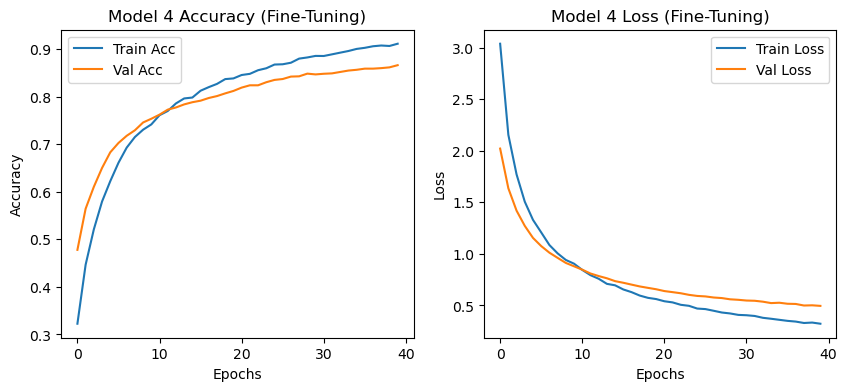

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history_4.history["accuracy"], label="Train Acc")
plt.plot(history_4.history["val_accuracy"], label="Val Acc")
plt.title("Model 4 Accuracy (Fine-Tuning)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history_4.history["loss"], label="Train Loss")
plt.plot(history_4.history["val_loss"], label="Val Loss")
plt.title("Model 4 Loss (Fine-Tuning)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [34]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_4.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [4]:
import tensorflow as tf
model = tf.keras.models.load_model("best_model_4.keras")


In [8]:
# Use SAME class order used during training
import os
class_names = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print("Total Classes =", len(class_names))
print(class_names[:10])

Total Classes = 247
['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']


In [9]:
import os
os.path.exists(r"C:\Users\94772\Desktop\A.png")


True

In [56]:
model.evaluate(test_ds)


116/116 ━━━━━━━━━━━━━━━━━━━━ 70s 534ms/step - accuracy: 0.8713 - loss: 0.4711


[0.4623347520828247, 0.878853440284729]

In [91]:
import os

DATASET_PATH = r"C:\Users\94772\Desktop\Abdullah_project\Tamil_Character_Recognition\dataset_raw"

class_names = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

NUM_CLASSES = len(class_names)

print("Classes =", NUM_CLASSES)
print(class_names[:10])


Classes = 247
['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']


In [61]:
import tensorflow as tf
import numpy as np

def predict_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, (224,224))

    # IMPORTANT — same preprocessing as training
    img = tf.keras.applications.efficientnet.preprocess_input(img)

    img = tf.expand_dims(img, axis=0)

    preds = model.predict(img)

    top5 = preds[0].argsort()[-5:][::-1]

    print("\nTop Predictions:")
    for i in top5:
        print(class_names[i], "-->", round(float(preds[0][i])*100, 2), "%")


In [64]:
predict_image(r"C:\Users\94772\Desktop\A.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

Top Predictions:
1 --> 99.96 %
2 --> 0.01 %
191 --> 0.01 %
47 --> 0.0 %
81 --> 0.0 %


In [96]:
predict_image(r"C:\Users\94772\Desktop\Ko.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Top Predictions:
40 --> 30.09 %
42 --> 24.59 %
66 --> 17.52 %
52 --> 10.08 %
64 --> 5.38 %


Fine-Tune Round-2 (Unfreeze More Layers)

In [65]:
base_model = model_4.get_layer("efficientnetb0")
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.30)   # freeze 30%
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


In [68]:
model_4.compile(
    optimizer=tf.keras.optimizers.Adam(1e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
#Callback
checkpoint2 = tf.keras.callbacks.ModelCheckpoint(
    "best_model_5.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)



In [69]:
history_ft2 = model_4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[checkpoint2, early_stop]
)


Epoch 1/12
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.9118 - loss: 0.3143
Epoch 1: val_accuracy improved from -inf to 0.86773, saving model to best_model_5.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 497s 888ms/step - accuracy: 0.9118 - loss: 0.3143 - val_accuracy: 0.8677 - val_loss: 0.4954
Epoch 2/12
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.9183 - loss: 0.3079
Epoch 2: val_accuracy did not improve from 0.86773
541/541 ━━━━━━━━━━━━━━━━━━━━ 473s 874ms/step - accuracy: 0.9183 - loss: 0.3079 - val_accuracy: 0.8648 - val_loss: 0.5005
Epoch 3/12
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.9167 - loss: 0.3082
Epoch 3: val_accuracy did not improve from 0.86773
541/541 ━━━━━━━━━━━━━━━━━━━━ 474s 875ms/step - accuracy: 0.9167 - loss: 0.3082 - val_accuracy: 0.8637 - val_loss: 0.5001
Epoch 4/12
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.9149 - loss: 0.3075
Epoch 4: val_accuracy did not improve from 0.86773
541/541 ━━━━━━━━━━━━━━━━━━━━ 525s 970ms/step

In [92]:
import os

DATASET_PATH = r"C:\Users\94772\Desktop\Abdullah_project\Tamil_Character_Recognition\dataset_raw"

class_names = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

NUM_CLASSES = len(class_names)
print("Total Classes:", NUM_CLASSES)


Total Classes: 247


In [10]:
tamil_map = {
    "1":"அ","2":"ஆ","3":"இ","4":"ஈ","5":"உ","6":"ஊ",
    "7":"எ","8":"ஏ","9":"ஐ","10":"ஒ","11":"ஓ","12":"ஔ",

    # Mei ezhuththu
    "13":"க்","14":"ங்","15":"ச்","16":"ஞ்","17":"ட்","18":"ண்",
    "19":"த்","20":"ந்","21":"ப்","22":"ம்",
    "23":"ய்","24":"ர்","25":"ல்","26":"வ்",
    "27":"ழ்","28":"ள்","29":"ற்","30":"ன்",

    # க series
    "31":"க","32":"கா","33":"கி","34":"கீ","35":"கு","36":"கூ",
    "37":"கெ","38":"கே","39":"கை","40":"கொ","41":"கோ","42":"கௌ",

    # ங series
    "43":"ங","44":"ஙா","45":"ஙி","46":"ஙீ","47":"ஙு","48":"ஙூ",
    "49":"ஙெ","50":"ஙே","51":"ஙை","52":"ஙொ","53":"ஙோ","54":"ஙௌ",

    # ச series
    "55":"ச","56":"சா","57":"சி","58":"சீ","59":"சு","60":"சூ",
    "61":"செ","62":"சே","63":"சை","64":"சொ","65":"சோ","66":"சௌ",

    # ஞ series
    "67":"ஞ","68":"ஞா","69":"ஞி","70":"ஞீ","71":"ஞு","72":"ஞூ",
    "73":"ஞெ","74":"ஞே","75":"ஞை","76":"ஞொ","77":"ஞோ","78":"ஞௌ",

    # ட series
    "79":"ட","80":"டா","81":"டி","82":"டீ","83":"டு","84":"டூ",
    "85":"டெ","86":"டே","87":"டை","88":"டொ","89":"டோ","90":"டௌ",

    # ண series
    "91":"ண","92":"ணா","93":"ணி","94":"ணீ","95":"ணு","96":"ணூ",
    "97":"ணெ","98":"ணே","99":"ணை","100":"ணொ","101":"ணோ","102":"ணௌ",

    # த series
    "103":"த","104":"தா","105":"தி","106":"தீ","107":"து","108":"தூ",
    "109":"தெ","110":"தே","111":"தை","112":"தொ","113":"தோ","114":"தௌ",

    # ந series
    "115":"ந","116":"நா","117":"நி","118":"நீ","119":"நு","120":"நூ",
    "121":"நெ","122":"நே","123":"நை","124":"நொ","125":"நோ","126":"நௌ",

    # ப series
    "127":"ப","128":"பா","129":"பி","130":"பீ","131":"பு","132":"பூ",
    "133":"பெ","134":"பே","135":"பை","136":"பொ","137":"போ","138":"பௌ",

    # ம series
    "139":"ம","140":"மா","141":"மி","142":"மீ","143":"மு","144":"மூ",
    "145":"மெ","146":"மே","147":"மை","148":"மொ","149":"மோ","150":"மௌ",

    # ய series
    "151":"ய","152":"யா","153":"யி","154":"யீ","155":"யு","156":"யூ",
    "157":"யெ","158":"யே","159":"யை","160":"யொ","161":"யோ","162":"யௌ",

    # ர series
    "163":"ர","164":"ரா","165":"ரி","166":"ரீ","167":"ரு","168":"ரூ",
    "169":"ரெ","170":"ரே","171":"ரை","172":"ரொ","173":"ரோ","174":"ரௌ",

    # ல series
    "175":"ல","176":"லா","177":"லி","178":"லீ","179":"லு","180":"லூ",
    "181":"லெ","182":"லே","183":"லை","184":"லொ","185":"லோ","186":"லௌ",

    # வ series
    "187":"வ","188":"வா","189":"வி","190":"வீ","191":"வு","192":"வூ",
    "193":"வெ","194":"வே","195":"வை","196":"வொ","197":"வோ","198":"வௌ",

    # ழ series
    "199":"ழ","200":"ழா","201":"ழி","202":"ழீ","203":"ழு","204":"ழூ",
    "205":"ழெ","206":"ழே","207":"ழை","208":"ழொ","209":"ழோ","210":"ழௌ",

    # ள series
    "211":"ள","212":"ளா","213":"ளி","214":"ளீ","215":"ளு","216":"ளூ",
    "217":"ளெ","218":"ளே","219":"ளை","220":"ளொ","221":"ளோ","222":"ளௌ",

    # ற series
    "223":"ற","224":"றா","225":"றி","226":"றீ","227":"று","228":"றூ",
    "229":"றெ","230":"றே","231":"றை","232":"றொ","233":"றோ","234":"றௌ",

    # ன series
    "235":"ன","236":"னா","237":"னி","238":"னீ","239":"னு","240":"னூ",
    "241":"னெ","242":"னே","243":"னை","244":"னொ","245":"னோ","246":"னௌ",

    # last
    "247":"ஃ"
}


In [ ]:
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np


In [16]:
#Load Data set
DATASET_PATH =  r"C:\Users\94772\Desktop\Abdullah_project\Tamil_Character_Recognition\dataset_raw"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = val_test_ds.take(int(0.5 * len(val_test_ds)))
test_ds = val_test_ds.skip(int(0.5 * len(val_test_ds)))

NUM_CLASSES = len(train_ds.class_names)
print("Classes =", NUM_CLASSES)


Found 24700 files belonging to 247 classes.
Using 17290 files for training.
Found 24700 files belonging to 247 classes.
Using 7410 files for validation.
Classes = 247


In [17]:
import matplotlib.pyplot as plt
def predict_tamil(image_path, top_k=2):
    # Load original image
    img_raw = tf.io.read_file(image_path)
    img_raw = tf.image.decode_image(img_raw, channels=3)
    img_raw = tf.image.resize(img_raw, (224, 224))
    img_raw = tf.cast(img_raw, tf.float32)

    # Preprocess for model
    img = tf.keras.applications.efficientnet.preprocess_input(img_raw)
    img_batch = tf.expand_dims(img, axis=0)

    # Predict
    preds = model.predict(img_batch)[0]
    top_indices = np.argsort(preds)[-top_k:][::-1]

    # Show original image
    plt.imshow(img_raw / 255.0)
    plt.axis("off")
    plt.show()

    print("\nTop Predictions:")
    for idx in top_indices:
        folder = class_names[idx]
        tamil_letter = tamil_map.get(folder, "Unknown")
        confidence = preds[idx] * 100
        print(f"{folder} ({tamil_letter}) --> {confidence:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


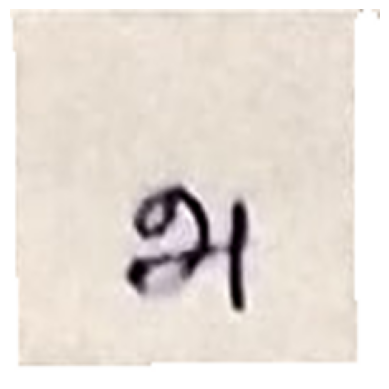


Top Predictions:
1 (அ) --> 99.96%
2 (ஆ) --> 0.01%


In [18]:
predict_tamil(r"C:\Users\94772\Desktop\A.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


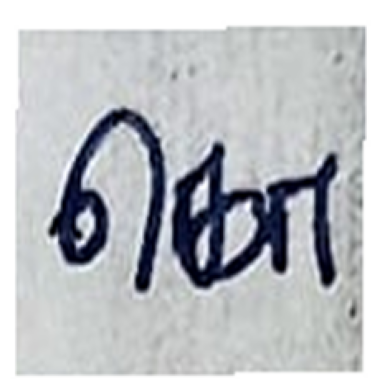


Top Predictions:
40 (கொ) --> 30.09%
42 (கௌ) --> 24.59%


In [19]:
predict_tamil(r"C:\Users\94772\Desktop\Ko.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


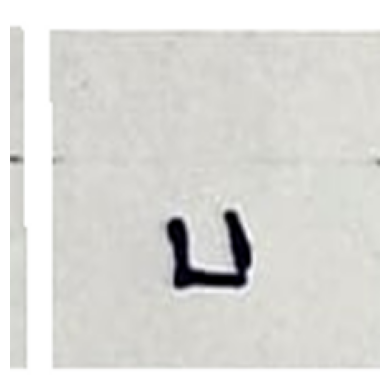


Top Predictions:
127 (ப) --> 99.25%
21 (ப்) --> 0.49%


In [ ]:
predict_tamil(r"C:\Users\94772\Desktop\pa.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


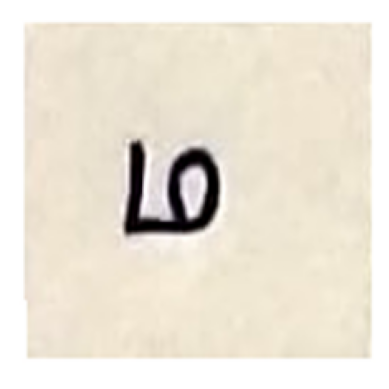


Top Predictions:
139 (ம) --> 99.71%
22 (ம்) --> 0.11%


In [21]:
predict_tamil(r"C:\Users\94772\Desktop\ma.png")
